In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.16.2
Num GPUs Available: 1


## 1. Data Preprocessing

In [17]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the dataset
dataset = pd.read_csv('../data/Churn_Modelling.csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [18]:
## Selects features (X) and target variable (y).
# iloc[:, 3:13] → takes columns 3 to 12 (customer info) as features.
# iloc[:, 13] → takes column 13 (whether the customer exited = churn) as labels.

X = dataset.iloc[:, 3:13]
y = dataset.iloc[:, 13]

### Replace categorical text data (Geography, Gender) with numeric columns that a (ANN) neural network can understand.
#### get_dummies() converts categorical text values into numeric binary columns (one-hot encoding).

Example with "Geography" column:

| France | Spain | Germany |
| ------ | ----- | ------- |
| 1      | 0     | 0       |
| 0      | 1     | 0       |
| 0      | 0     | 1       |
| 1      | 0     | 0       |

After drop_first = True

| Spain | Germany |                            |
| ----- | ------- | -------------------------- |
| 0     | 0       | (→ France is implied here) |
| 1     | 0       |                            |
| 0     | 1       |                            |
| 0     | 0       |                            |



#### 👉 Now: If both Spain=0 and Germany=0, it means France.


### Same logic for Gender

"Gender" originally has Male and Female.

With drop_first=True, we keep only Male (for example):

| Male |
| ---- |
| 1    |
| 0    |


👉 If Male=1 → person is male.
👉 If Male=0 → person is female.



In [19]:
# Create dummy variables
geography = pd.get_dummies(X["Geography"], drop_first=True)
gender = pd.get_dummies(X['Gender'], drop_first=True)

# Concatenate the Data Frames
X = pd.concat([X, geography, gender], axis=1)

# Drop Unnecessary columns ## since, ANN needs numbers, not text so drop text/string columns
# Neural networks (and most ML algorithms) cannot work directly with text, they need numeric input.
# Solution: One-hot encoding (dummy variables)
X = X.drop(['Geography', 'Gender'], axis=1)

### Splits the dataset into training (80%) and testing (20%) sets.

In [14]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

### Feature scaling → standardizes data (mean = 0, std = 1).

#### ANN performance improves when inputs are scaled.

fit_transform → learns scaling from training data and applies it.

transform → applies the same scaling to test data.

In [15]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## 2. Build the ANN!

### Import TensorFlow and Keras modules. (Now, keras is comes along with tensorflow 2.x)

Sequential → linear stack of layers.

Dense → fully connected (ANN) layer.

Dropout → randomly drops neurons to reduce overfitting (optional).

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Initialising the ANN model as a sequential stack.
classifier = Sequential()

#### Adds the first hidden layer.

units=6 → 6 neurons.

kernel_initializer='he_uniform' → weight initialization method.

activation='relu' → activation function (introduces non-linearity).

input_dim=11 → number of input features (11 columns in X).

In [22]:
classifier.add(Dense(units=6, kernel_initializer='he_uniform',activation='relu', input_dim=11))

/Users/baqirrizvi/Desktop/ai/DeepLearning/deeplearning/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-08-31 17:23:07.616389: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-08-31 17:23:07.616517: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-08-31 17:23:07.616531: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-08-31 17:23:07.616589: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-08-31 17:23:07.616614: I tensorflow/core/common_runtime/pluggable_device/pluggabl

In [23]:
classifier.add(Dense(units=6, kernel_initializer='he_uniform', activation='relu'))

## Adds the output layer.
# units=1 → single output neuron (binary classification: churn or not).
# activation='sigmoid' → outputs probability between 0 and 1.
classifier.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))


#### Compiles the ANN (sets training configuration).

optimizer='adamax' → optimization algorithm.

loss='binary_crossentropy' → loss function for binary classification.

metrics=['accuracy'] → track accuracy during training.

In [24]:
classifier.compile(optimizer='adamax', loss='binary_crossentropy', metrics=['accuracy'])

#### Trains the ANN on training data.

validation_split=0.33 → uses 33% of training data for validation.

batch_size=10 → updates weights after every 10 samples.

epochs=100 → number of training iterations over the dataset.

verbose=1 → prints progress.

###### model_history stores loss/accuracy values for plotting later.

### classifier.fit(...)

This is the method that trains the model on the data.

It adjusts the weights of your ANN using backpropagation + optimizer (Adamax in our case).

### validation_split=0.33

33% of the training data is reserved for validation.

Validation data is not used to train weights, only to check performance after each epoch.

Helps detect overfitting (when training accuracy is high but validation accuracy is low).

### batch_size=10

Training data is split into mini-batches of 10 samples.

The ANN updates its weights after each batch (not after the whole dataset).

Why? → Speeds up training and makes gradient descent more stable.

### epochs=100

The model will go through the entire training dataset 100 times.

More epochs = more chances to learn, but also risk of overfitting.

Each epoch consists of multiple batch updates.

### verbose=1

Controls the training output:

0 → silent

1 → progress bar for each epoch (default)

2 → one line per epoch

### model_history

Stores training history in a dictionary format.

In [25]:
model_history = classifier.fit(
    X_train, y_train, validation_split=0.33,
    batch_size=10, epochs=100, verbose=1
)

Epoch 1/100


2025-08-31 17:27:27.760894: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5425 - loss: 0.8385 - val_accuracy: 0.6202 - val_loss: 0.6696
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7057 - loss: 0.5995 - val_accuracy: 0.7645 - val_loss: 0.5535
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7835 - loss: 0.5283 - val_accuracy: 0.7925 - val_loss: 0.5179
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7932 - loss: 0.5045 - val_accuracy: 0.7978 - val_loss: 0.5031
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7964 - loss: 0.4932 - val_accuracy: 0.7989 - val_loss: 0.4930
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7979 - loss: 0.4845 - val_accuracy: 0.7989 - val_loss: 0.4852
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8005 - loss: 0.4781 - val_accuracy: 0.7993 - val_loss: 0.4798
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8022 - loss: 0.4724 - val_accuracy: 0.8001

## 3. Visualizing Results

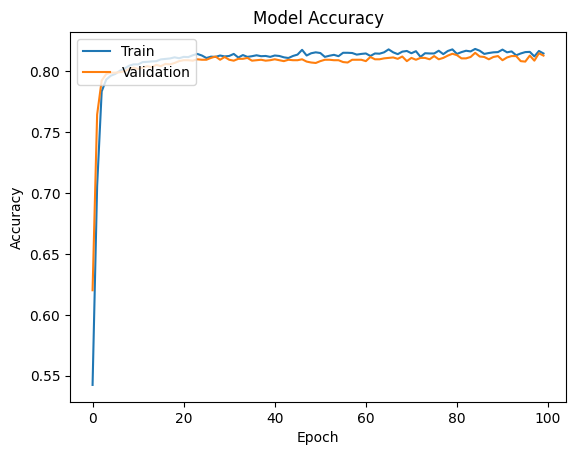

In [26]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

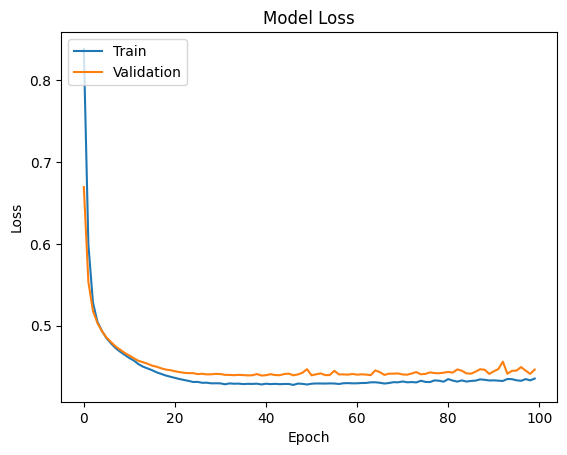

In [27]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## 4. Predictions & Evaluation

### Uses the trained ANN to predict probabilities on test data.

#### Converts probabilities to True/False (churn if > 0.5).

In [28]:
y_pred = (classifier.predict(X_test) > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [29]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
score = accuracy_score(y_test, y_pred)

In [30]:
print("Confusion Matrix:\n", cm)
print("Accuracy Score:", score)

Confusion Matrix:
 [[1519   76]
 [ 286  119]]
Accuracy Score: 0.819
